# Notebook 2 · Hard problems as bitstring search

Many discrete problems can be written as a compact candidate string plus a
check or score. The string is not the whole model; it is the representation of
one proposed answer.

This notebook stays classical. It uses exhaustive enumeration only because the
examples are tiny enough to inspect by hand.


In [1]:
from itertools import permutations, product

import matplotlib.pyplot as plt
import numpy as np

np.set_printoptions(precision=3, suppress=True)

## Subset sum

Given weights $w_1,\ldots,w_n$ and a target $T$, choose a subset whose sum is
exactly $T$. A bit $z_i=1$ means that item $i$ is included:
$$
S(z)=\sum_i z_i w_i .
$$

A candidate is feasible when $S(z)=T$. If no exact subset exists, the same code
can rank candidates by distance $|S(z)-T|$.


In [2]:
weights = np.array([3, 5, 6, 7, 9])
target = 15

subset_rows = []
for bits in product([0, 1], repeat=len(weights)):
    z = np.array(bits)
    total = int(z @ weights)
    error = abs(total - target)
    subset_rows.append(("".join(map(str, bits)), total, error))

closest_rows = sorted(subset_rows, key=lambda row: (row[2], row[0]))
for bitstring, total, error in closest_rows[:8]:
    print(f"z={bitstring} | sum={total:2d} | |sum-target|={error}")

z=00101 | sum=15 | |sum-target|=0
z=11010 | sum=15 | |sum-target|=0
z=00011 | sum=16 | |sum-target|=1
z=01001 | sum=14 | |sum-target|=1
z=10110 | sum=16 | |sum-target|=1
z=11100 | sum=14 | |sum-target|=1
z=00110 | sum=13 | |sum-target|=2
z=11001 | sum=17 | |sum-target|=2


## Visualise subset-sum candidates

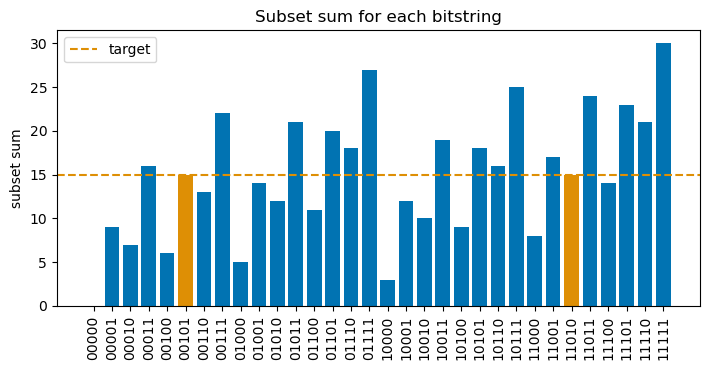

In [3]:
labels = [row[0] for row in subset_rows]
totals = np.array([row[1] for row in subset_rows])
errors = np.array([row[2] for row in subset_rows])
colors = np.where(errors == 0, "#DE8F05", "#0173B2")

plt.figure(figsize=(7.2, 3.8))
plt.bar(np.arange(len(totals)), totals, color=colors)
plt.axhline(target, color="#DE8F05", linestyle="--", label="target")
plt.xticks(np.arange(len(errors)), labels, rotation=90)
plt.ylabel("subset sum")
plt.title("Subset sum for each bitstring")
plt.legend()
plt.tight_layout()
plt.savefig("subset_sum_landscape.png", dpi=110)
plt.show()

## Travelling salesperson problem

For $m$ cities, a tour is an ordering of the cities. One common binary encoding
uses $z_{i,t}=1$ when city $i$ is visited at position $t$. That encoding needs
constraints: each city appears once and each position contains one city.

The small demo below enumerates tours directly, then visualises the shortest
one. This keeps the modelling idea visible without introducing a full quadratic
form.


In [4]:
city_names = ["A", "B", "C", "D"]
coords = np.array(
    [
        [0.0, 0.0],
        [1.0, 0.2],
        [0.8, 1.1],
        [0.1, 0.9],
    ]
)

dist = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)

def tour_length(tour: tuple[int, ...]) -> float:
    return float(
        sum(dist[tour[i], tour[(i + 1) % len(tour)]] for i in range(len(tour)))
    )


start = 0
tours = []
for rest in permutations([1, 2, 3]):
    tour = (start, *rest)
    tours.append((tour_length(tour), tour))
tours.sort(key=lambda row: row[0])

for length, tour in tours:
    route = " -> ".join(city_names[i] for i in (*tour, tour[0]))
    print(f"{route}: {length:.3f}")

A -> B -> C -> D -> A: 3.575
A -> D -> C -> B -> A: 3.575
A -> B -> D -> C -> A: 4.248
A -> C -> D -> B -> A: 4.248
A -> C -> B -> D -> A: 4.328
A -> D -> B -> C -> A: 4.328


## Visualise the shortest TSP tour

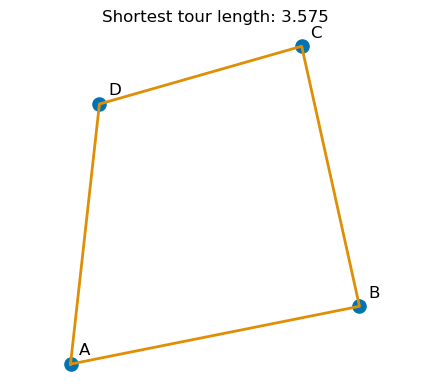

In [5]:
best_length, best_tour = tours[0]
closed = np.array([*best_tour, best_tour[0]])

plt.figure(figsize=(4.4, 4.0))
plt.scatter(coords[:, 0], coords[:, 1], s=90, color="#0173B2")
for name, (x, y) in zip(city_names, coords):
    plt.text(x + 0.03, y + 0.03, name, fontsize=12)
plt.plot(coords[closed, 0], coords[closed, 1], color="#DE8F05", linewidth=2)
plt.title(f"Shortest tour length: {best_length:.3f}")
plt.axis("equal")
plt.axis("off")
plt.tight_layout()
plt.savefig("tsp_four_city_route.png", dpi=110)
plt.show()

## 3SAT

In 3SAT, each clause contains three literals and the question is whether there
is a truth assignment that satisfies all clauses. With variables
$x_1,x_2,x_3$, the assignment itself is again a bitstring.


In [6]:
def eval_literal(bits: tuple[int, ...], literal: int) -> bool:
    value = bool(bits[abs(literal) - 1])
    return value if literal > 0 else not value


clauses = [
    (1, -2, 3),
    (-1, 2, 3),
    (1, 2, -3),
    (-1, -2, -3),
]

sat_rows = []
for bits in product([0, 1], repeat=3):
    satisfied = [
        any(eval_literal(bits, literal) for literal in clause)
        for clause in clauses
    ]
    unsatisfied = len(clauses) - sum(satisfied)
    sat_rows.append(("".join(map(str, bits)), unsatisfied))

for bitstring, unsatisfied in sat_rows:
    status = "satisfying" if unsatisfied == 0 else f"{unsatisfied} unsatisfied"
    print(f"x={bitstring}: {status}")

x=000: satisfying
x=001: 1 unsatisfied
x=010: 1 unsatisfied
x=011: satisfying
x=100: 1 unsatisfied
x=101: satisfying
x=110: satisfying
x=111: 1 unsatisfied


## Visualise 3SAT assignments

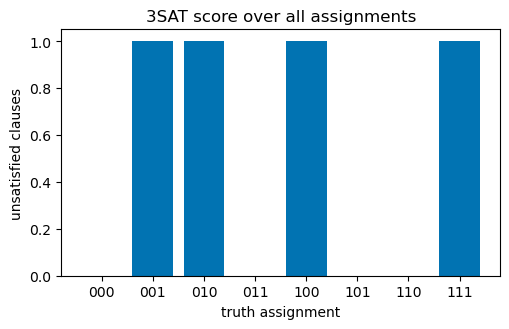

In [7]:
plt.figure(figsize=(5.2, 3.4))
plt.bar(
    [row[0] for row in sat_rows],
    [row[1] for row in sat_rows],
    color=["#DE8F05" if row[1] == 0 else "#0173B2" for row in sat_rows],
)
plt.xlabel("truth assignment")
plt.ylabel("unsatisfied clauses")
plt.title("3SAT score over all assignments")
plt.tight_layout()
plt.savefig("three_sat_assignments.png", dpi=110)
plt.show()

## The shared pattern

Subset sum, routing, and 3SAT use different checks, but the computational shape
is similar:

1. encode a candidate answer;
2. evaluate whether it is valid and how good it is;
3. search the candidate space without enumerating it whenever possible.

Quantum circuits also end in measured bitstrings. That makes them compatible
with this representation, but the modelling burden remains: the problem still
has to be encoded, sampled, and verified.
